# **Image Classification Using Pre-trained Models**

### **Laboratory Exercise 6** - *Deep Learning Fundamentals*
*From the course module:* ***E1 - CNN Implementation*** *(Laboratory Task 6)*

**Instructions:**
1. Look for a suitable image classification dataset, or create your own custom dataset following the procedure demonstrated during the previous class discussion.
2. Curate and organize the dataset appropriately for an image classification task.
3. Create a custom PyTorch Dataset class to load and process the curated dataset.
4. Create appropriate DataLoader objects for loading the dataset in batches for model evaluation.
5. Perform model inference using different trained/pre-trained models available from torchvision.models.
6. Evaluate and compare up to five (5) different models using appropriate performance metrics, such as accuracy, precision, recall, and F1-score.
7. Present the comparison of the models clearly using a table and/or appropriate visualizations.
8. Write a short analysis and conclusion discussing the results. Explain possible reasons why the models produced different levels of performance, considering factors such as model architecture, model complexity, input requirements, and suitability for the selected dataset.


## **Implementation**



### **Import PyTorch and set up libraries**

In [2]:
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

Looking in indexes: https://download.pytorch.org/whl/cu126
  Using cached torchaudio-2.11.0%2Bcu126-cp314-cp314-win_amd64.whl.metadata (7.0 kB)
   ---------------------------------------- 0.0/2.6 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.6 GB 32.1 MB/s eta 0:01:22
   ---------------------------------------- 0.0/2.6 GB 35.8 MB/s eta 0:01:13
   ---------------------------------------- 0.0/2.6 GB 36.6 MB/s eta 0:01:12
   ---------------------------------------- 0.0/2.6 GB 33.7 MB/s eta 0:01:18
   ---------------------------------------- 0.0/2.6 GB 30.9 MB/s eta 0:01:24
    --------------------------------------- 0.0/2.6 GB 28.8 MB/s eta 0:01:30
    --------------------------------------- 0.0/2.6 GB 27.3 MB/s eta 0:01:35
    --------------------------------------- 0.0/2.6 GB 26.1 MB/s eta 0:01:39
    --------------------------------------- 0.0/2.6 GB 25.3 MB/s eta 0:01:42
    --------------------------------------- 0.1/2.6 GB 24.6 MB/s eta 0:01:45
    -------------

In [3]:
import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import torchvision
from torchvision import datasets, transforms
from torchvision import models

import cv2
import matplotlib.pyplot as plt

In [4]:
print(torch.cuda.is_available())       
print(torch.cuda.get_device_name(0)) 

True
NVIDIA GeForce RTX 3060 Laptop GPU


### **Get the data**

The data we're going to be using is a subset of the Food101 dataset.

Food101 is popular computer vision benchmark as it contains 1000 images of 101 different kinds of foods, totaling 101,000 images (75,750 train and 25,250 test). Instead of 101 food classes though, we're going to start with 3: pizza, steak and sushi.

In [5]:
os.listdir('pizza_steak_sushi/train')

['pizza', 'steak', 'sushi']

In [6]:
root = 'pizza_steak_sushi/train'

### **Data preparation**

At the beginning of any new machine learning problem, it's paramount to understand the data you're working with. Here we'll take some steps to figure out what data we have.

In our case, we have images of pizza, steak and sushi in standard image classification format. Image classification format contains separate classes of images in separate directories titled with a particular class name. For example, all images of pizza are contained in the pizza/ directory.

In [7]:
classes = sorted(os.listdir(root))
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [8]:
data_dict = {'X':[], 'y':[]}

for cls in classes:
    cls_path = os.path.join(root, cls)
    for img in os.listdir(cls_path):
        img_path = os.path.join(cls_path, img)
        data_dict['X'].append(img_path)
        data_dict['y'].append(class_to_idx[cls])

In [9]:
pd.DataFrame(data_dict).head(10)

,X,y
0,pizza_steak_sushi/train\pizza\1008844.jpg,0
1,pizza_steak_sushi/train\pizza\1033251.jpg,0
2,pizza_steak_sushi/train\pizza\1044789.jpg,0
3,pizza_steak_sushi/train\pizza\1089334.jpg,0
4,pizza_steak_sushi/train\pizza\1105700.jpg,0
5,pizza_steak_sushi/train\pizza\12301.jpg,0
6,pizza_steak_sushi/train\pizza\1285298.jpg,0
7,pizza_steak_sushi/train\pizza\138855.jpg,0
8,pizza_steak_sushi/train\pizza\1412034.jpg,0
9,pizza_steak_sushi/train\pizza\1524655.jpg,0


**Visualize an image**

Random image path: pizza_steak_sushi/train\sushi\148799.jpg
Image class: 2
Image height: 512
Image width: 384


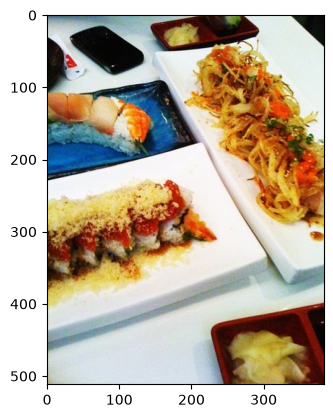

In [10]:
random.seed(42)

img_path = random.choice(data_dict['X'])
img_class = data_dict['y'][data_dict['X'].index(img_path)]
img = cv2.imread(img_path)

print(f"Random image path: {img_path}")
print(f"Image class: {img_class}")
print(f"Image height: {img.shape[0]}")
print(f"Image width: {img.shape[1]}")

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

### **Transforming the data**

Before we can use our image data with PyTorch we need to:

1. Turn it into tensors (numerical representations of our images).
2. Turn it into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`, we'll call these Dataset and DataLoader for short.

Since we're working with a vision problem, we'll be looking at `torchvision.datasets` for our data loading functions as well as `torchvision.transforms` for preparing our data.

To get experience with torchvision.transforms, let's write a series of transform steps that:

1. Resize the images using `transforms.Resize()` (from about 512x512 to 64x64, the same shape as the images on the CNN Explainer website).
2. Flip our images randomly on the horizontal using `transforms.RandomHorizontalFlip()` (this could be considered a form of data augmentation because it will artificially change our image data).
3. Turn our images from an image to a PyTorch tensor using `transforms.ToTensor()`.

We can compile all of these steps using torchvision.transforms.Compose().

In [ ]:
data_transform = transforms.Compose([
    # Resize the images to 64x64
    transforms.Resize(size=(64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p=0.5), # p = probability of flip, 0.5 = 50% chance
    # Turn the image into a torch.Tensor
    transforms.ToTensor() # this also converts all pixel values from 0 to 255 to be between 0.0 and 1.0 
])

### **Loading image data with a custom Dataset**

### **Data Augmentation**

In [ ]:
class CustomDataset(Dataset):
    def __init__(self, data_dict: dict, transforms=None):
        self.data_dict = data_dict
        self.transforms = transforms

    def __getitem__(self, idx):
        x = cv2.imread(self.data_dict['X'][idx])
        y = self.data_dict['y'][idx]
        if self.transforms:
            x = self.transforms(x)
            y = torch.tensor(y)
        return x, y

    def __len__(self):
        return len(self.data_dict['X'])

In [ ]:
trans = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize(size=(300, 300)),
    transforms.Normalize(mean=[0, 0, 0], std=[1, 1, 1])
])

cd = CustomDataset(data_dict, trans)

In [ ]:
for i in cd:
    print(i[0].shape)

### **Model 1: ResNet-18**

A robust, lightweight baseline architecture that trains quickly and handles transfer learning effectively.

In [ ]:
model = models.resnet50(
    weights=models.ResNet50_Weights.DEFAULT
)

### **Model 2: DenseNet-161**

Uses dense feature reuse across layers, making it exceptional at capturing subtle textural and structural details unique to various food dishes.

### **Model 3: VGG-16**

A classic, deep convolutional network with a straightforward and uniform architecture that learns rich spatial features.

### **Model 4: MobileNet V2**

A lightweight, efficient architecture designed for faster training and lower memory usage while retaining strong classification performance.

### **Model 5: ResNeXt-50 32x4d**

Combines residual connections with grouped convolutions (cardinality), offering high capacity and accuracy for complex multi-class datasets.

### **Compare model results**

Let's compare our different models' loss curves and see which performed better and discuss some options for improving performance.